In [ ]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, find_peaks

def baseline_als(y, lam=1e5, p=0.01, niter=10):
    # ПРИНУДИТЕЛЬНО делаем массив одномерным
    y = np.asarray(y).flatten() 
    
    L = len(y)
    # Матрица разностей второго порядка
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L-2, L))
    # Матрица произведения D.T * D дает размер L x L
    DT_D = lam * D.transpose().dot(D)
    
    w = np.ones(L)
    z = np.zeros(L)
    
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        # Теперь размеры (L,L) + (L,L) совпадают
        Z = W + DT_D
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z
def preprocess_spectrum(intensity, lam=3e3, p=7e-3, polyorder=6, window_length=21):
    """
    Полный пайплайн предобработки одного спектра.
    input: np.array (интенсивности)
    """
    # 1. Удаление базовой линии (ALS)
    # Важно: делаем ПЕРЕД нормализацией
    baseline = baseline_als(intensity, lam=lam, p=p)
    y_no_bg = intensity - baseline
    
    # 2. Сглаживание (Savitzky-Golay)
    # window_length должен быть нечетным. 11-15 обычно хватает.
    y_smooth = savgol_filter(y_no_bg, window_length=window_length, polyorder=polyorder)
    y_noise = y_no_bg - y_smooth  # для анализа шума, если нужно
    
    # 3. Нормализация (L2)
    # Приводим вектор к единичной длине
    norm_l2 = np.linalg.norm(y_smooth)
    y_norm = y_smooth / norm_l2 if norm_l2 > 0 else y_smooth
    
    # 4. Вычисление производных
    # Используем тот же Savitzky-Golay, чтобы не плодить шум
    deriv_1 = savgol_filter(y_norm, window_length=window_length, polyorder=polyorder, deriv=1)
    deriv_2 = savgol_filter(y_norm, window_length=window_length, polyorder=polyorder, deriv=2)
    
    return {
        "clean": y_norm,
        "d1": deriv_1,
        "d2": deriv_2,
        "baseline": baseline,
        "noise": y_noise
    }

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---
# Предположим, x_grid — твой массив частот 926-2002
# raw_intensity — твой np.array интенсивностей


# Теперь у тебя есть:
# results['clean'] - чистый спектр для классификации
# results['d1'] - первая производная
# results['d2'] - вторая производная

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
spectra_map_df = pd.read_csv(
	'../../../control/mk1/cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt',
	sep='\t',
	skiprows=1,
    names=['X', 'Y', 'Wave', 'Intensity']
)
spectra_grouped = spectra_map_df.groupby(["X", "Y"]).agg({
    "Wave": list,
    "Intensity": list,
}).reset_index()


/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/4013227096.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  wave = spectra_grouped[spectra_grouped['X'] == spectra_grouped['X'][index]][spectra_grouped['Y'] == spectra_grouped['Y'][index]]["Wave"]
/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/4013227096.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  intensity = spectra_grouped[spectra_grouped['X'] == spectra_grouped['X'][index]][spectra_grouped['Y'] == spectra_grouped['Y'][index]]["Intensity"]


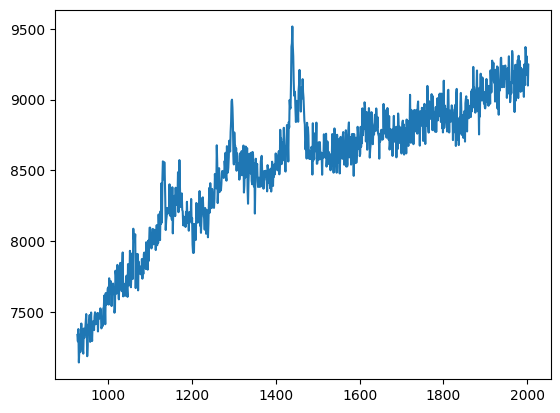

In [104]:
index = 3
wave = spectra_grouped[spectra_grouped['X'] == spectra_grouped['X'][index]][spectra_grouped['Y'] == spectra_grouped['Y'][index]]["Wave"]
intensity = spectra_grouped[spectra_grouped['X'] == spectra_grouped['X'][index]][spectra_grouped['Y'] == spectra_grouped['Y'][index]]["Intensity"]
plt.plot(wave[index], intensity[index])

In [41]:
np.array(intensity[index])

array([12803.853516, 13013.024414, 12979.162109, ..., 11486.722656,
       11415.90918 , 11524.832031], shape=(1015,))

In [42]:
intensity_als = baseline_als(np.array(intensity[index]))

/Users/igor/code/events/NuclearIThack_2026/deeppick_mephi_2026/ml/.venv/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/444241628.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/2918529503.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


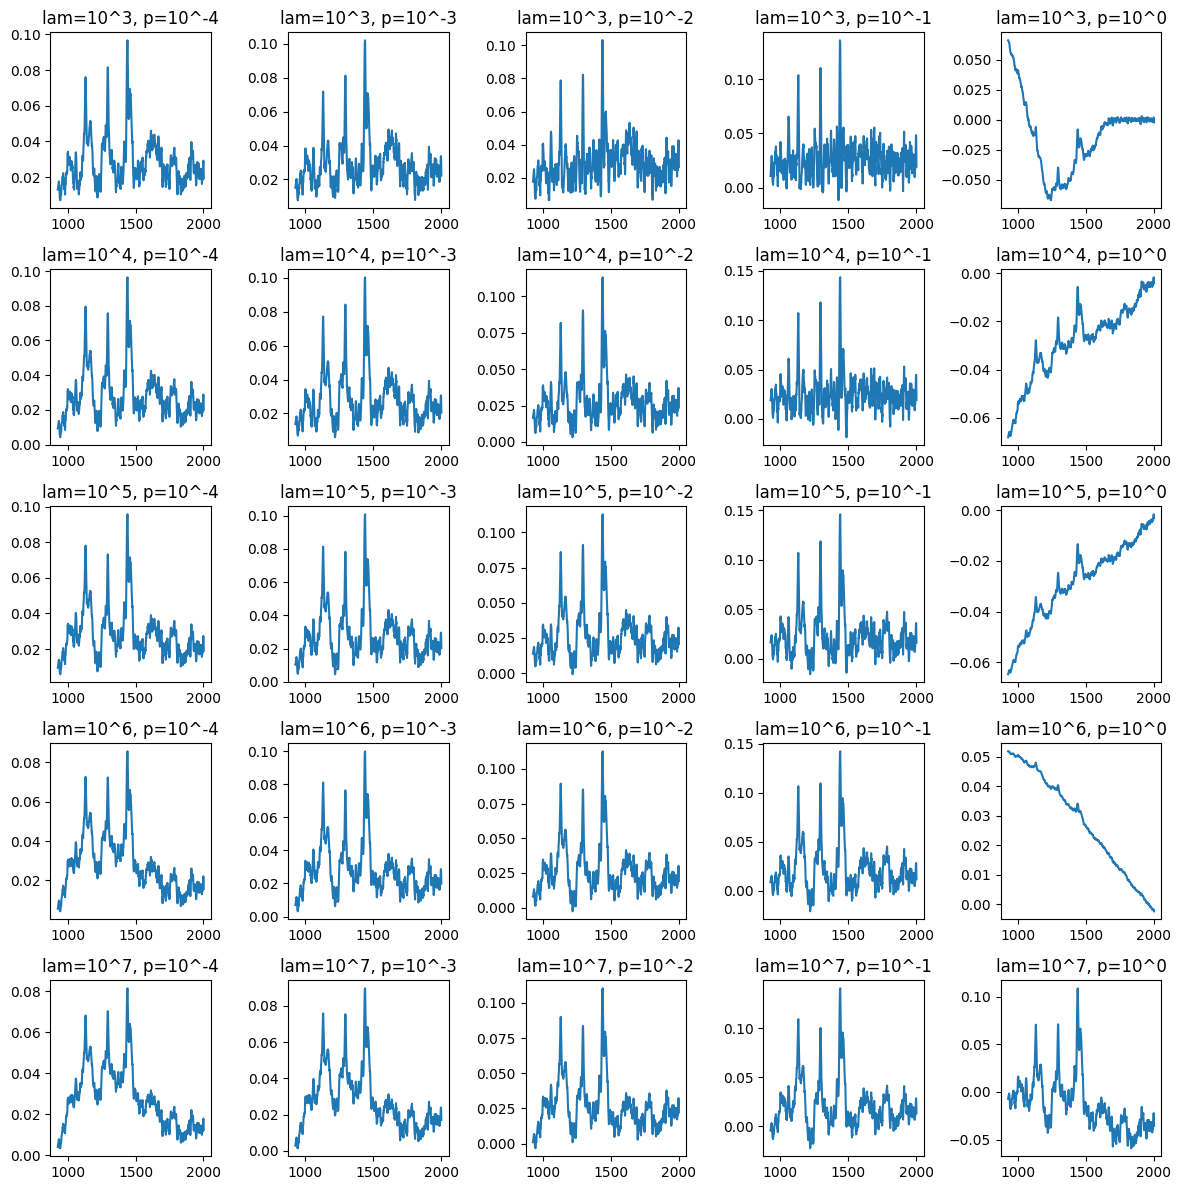

In [68]:
n, k = 5, 5
fig, ax = plt.subplots(n, k, figsize=(12, 12))
for i in range(n):
    for j in range(k):
        ax[i, j].plot(wave[index], preprocess_spectrum(np.array(intensity[index]), lam=10**(3+i), p=10**(-4+j))["clean"])
        ax[i, j].set_title(f"lam=10^{3+i}, p=10^{-4+j}")
plt.tight_layout()


/Users/igor/code/events/NuclearIThack_2026/deeppick_mephi_2026/ml/.venv/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/1511813299.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


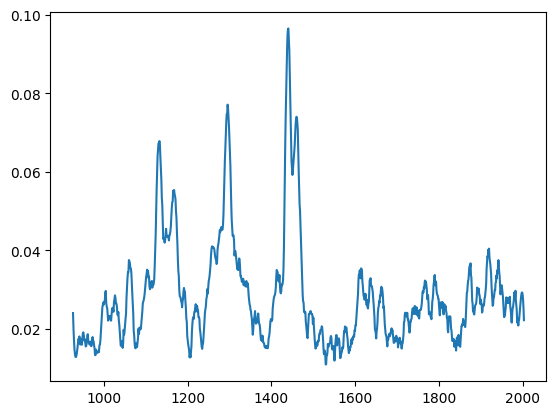

In [108]:

plt.plot(wave[index], preprocess_spectrum(np.array(intensity[index]), lam=1e5, p=1e-3, polyorder=3, window_length=21)["clean"])
spectrum_clean = preprocess_spectrum(np.array(intensity[index]), lam=1e5, p=1e-3, polyorder=3, window_length=21)["clean"]
plt.show()

In [116]:
peaks = find_peaks(spectrum_clean, height=0.03)  # height - минимальная высота пика, можно настроить
peaks

(array([ 55,  63,  66,  68,  86,  88,  90, 111, 115, 131, 133, 214, 217,
        238, 240, 243, 343, 368, 370, 390, 393, 537, 555, 570, 575, 581,
        645, 648, 653, 655, 660, 664, 667, 673, 677, 689, 703, 706, 721,
        723, 733, 783, 804, 806, 817, 821, 826, 835, 837, 849, 851, 857,
        859, 861, 899, 901]),
 {'peak_heights': array([0.03110738, 0.03750239, 0.0348647 , 0.03359127, 0.04044061,
         0.04015293, 0.03846786, 0.03024871, 0.03053654, 0.03669082,
         0.03601234, 0.03206283, 0.03373873, 0.03202022, 0.03232571,
         0.03069783, 0.03073402, 0.03290325, 0.03243172, 0.03540772,
         0.03493344, 0.0740147 , 0.0964982 , 0.03132678, 0.03371032,
         0.03501274, 0.03159437, 0.03219953, 0.0320758 , 0.03277386,
         0.03345464, 0.03794498, 0.03543483, 0.0398024 , 0.04393769,
         0.07710347, 0.04590992, 0.04511438, 0.04092038, 0.0410113 ,
         0.03013338, 0.03042648, 0.05535263, 0.05519974, 0.04360742,
         0.04549224, 0.04315968, 0.067817

/var/folders/sr/0bnz0x_x4t1d6x3ntv9ldmcc0000gn/T/ipykernel_79983/3432493371.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


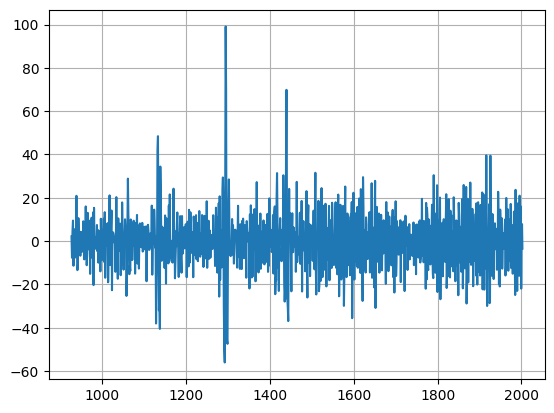

In [181]:
intensity_mean = np.array([0.0]*1015)

for _, row in spectra_grouped.iterrows():
    wave = row['Wave']
    intensity = row['Intensity']
    # Здесь можно вызвать preprocess_spectrum для каждого спектра
    intensity_mean += np.array(intensity)/len(spectra_grouped)

processed_spectra_mean = preprocess_spectrum(intensity_mean, lam=3e3, p=7e-3, polyorder=6, window_length=21)["noise"]
plt.plot(wave, processed_spectra_mean)
plt.grid()
plt.show()


In [127]:
len(spectra_grouped)

525